# Cat vs Dog

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss
from tqdm import tqdm
import pickle

from utilities import load_data

## 2. Load & preprocess data

In [7]:
X_train, y_train, X_test, y_test = load_data()

print("raw shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

raw shapes: (1000, 64, 64) (1000, 1) (200, 64, 64) (200, 1)


In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(X_train.shape[0], -1).T
X_test = X_test.reshape(X_test.shape[0], -1).T

y_train = y_train.reshape(1, -1)
y_test = y_test.reshape(1, -1)

print("Dim: ", X_train.shape, y_train.shape)

Dim:  (4096, 1000) (1, 1000)


## 3. Visualisation

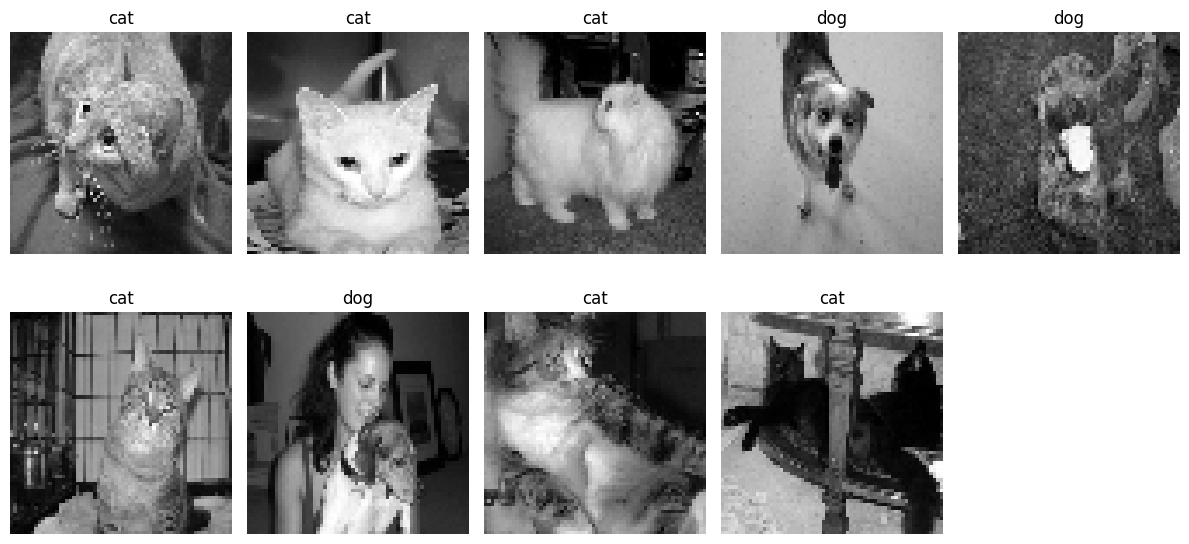

In [9]:
plt.figure(figsize=(12, 6))
for i in range(1, 10):
    plt.subplot(2, 5, i)
    plt.imshow(X_train[:, i].reshape(64, 64), cmap='gray')
    plt.title('dog' if y_train[0, i] == 1 else 'cat')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. `04_ANN_profond.ipynb`

In [10]:
def initialisation(dimensions):
    parametres = {}
    C = len(dimensions)
    np.random.seed(1)
    for c in range(1, C):
        limit = np.sqrt(1 / dimensions[c - 1])
        parametres['W' + str(c)] = np.random.randn(dimensions[c], dimensions[c - 1]) * limit
        parametres['b' + str(c)] = np.zeros((dimensions[c], 1))
    return parametres

In [11]:
def forward_propagation(X, parametres):
    activations = {'A0': X}
    C = len(parametres) // 2
    for c in range(1, C + 1):
        Z = parametres['W' + str(c)].dot(activations['A' + str(c - 1)]) + parametres['b' + str(c)]
        activations['A' + str(c)] = 1 / (1 + np.exp(-Z))
    return activations

In [12]:
def back_propagation(y, parametres, activations):
    m = y.shape[1]
    C = len(parametres) // 2
    dZ = activations['A' + str(C)] - y
    gradients = {}
    for c in reversed(range(1, C + 1)):
        gradients['dW' + str(c)] = 1 / m * np.dot(dZ, activations['A' + str(c - 1)].T)
        gradients['db' + str(c)] = 1 / m * np.sum(dZ, axis=1, keepdims=True)
        if c > 1:
            dZ = np.dot(parametres['W' + str(c)].T, dZ) * activations['A' + str(c - 1)] * (1 - activations['A' + str(c - 1)])
    return gradients

In [13]:
def update(gradients, parametres, learning_rate):
    C = len(parametres) // 2
    for c in range(1, C + 1):
        parametres['W' + str(c)] -= learning_rate * gradients['dW' + str(c)]
        parametres['b' + str(c)] -= learning_rate * gradients['db' + str(c)]
    return parametres

In [14]:
def predict(X, parametres):
    activations = forward_propagation(X, parametres)
    C = len(parametres) // 2
    return activations['A' + str(C)] >= 0.5

In [15]:
def deep_neural_network(X_train, y_train, X_test, y_test,
                         hidden_layers=(64, 32, 16),
                         learning_rate=0.05, n_iter=3000):
    dimensions = list(hidden_layers)
    dimensions.insert(0, X_train.shape[0])
    dimensions.append(y_train.shape[0])
    parametres = initialisation(dimensions)
    C = len(parametres) // 2

    train_loss, train_acc, test_acc = [], [], []

    for i in tqdm(range(n_iter)):
        activations = forward_propagation(X_train, parametres)
        gradients = back_propagation(y_train, parametres, activations)
        parametres = update(gradients, parametres, learning_rate)

        if i % 10 == 0:
            Af = activations['A' + str(C)]
            train_loss.append(log_loss(y_train.flatten(), Af.flatten()))
            train_acc.append(accuracy_score(y_train.flatten(), predict(X_train, parametres).flatten()))
            test_acc.append(accuracy_score(y_test.flatten(), predict(X_test, parametres).flatten()))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='train loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='train acc')
    plt.plot(test_acc, label='test acc')
    plt.legend()
    plt.show()

    print(f"final train acc: {train_acc[-1]:.3f} | final test acc: {test_acc[-1]:.3f}")
    return parametres

## 5. Train

Tweak `hidden_layers`, `learning_rate`, `n_iter` here and re-run this cell as many times as you want.

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [01:30<00:00, 33.26it/s]


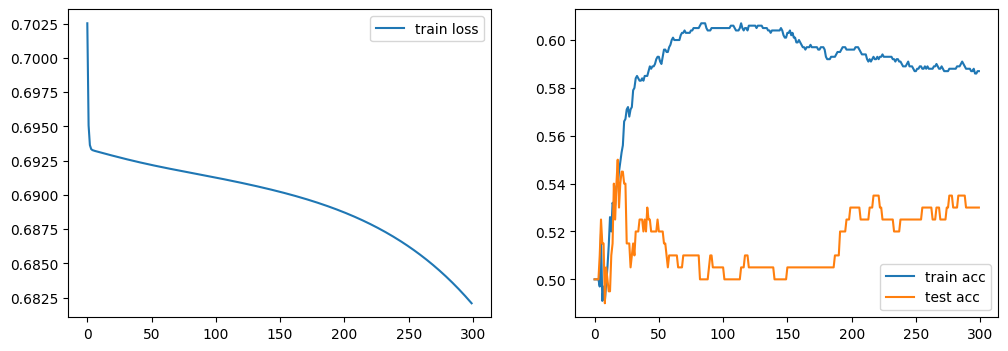

final train acc: 0.587 | final test acc: 0.530


In [16]:
parametres = deep_neural_network(
    X_train, y_train, X_test, y_test,
    hidden_layers=(64, 32, 16),
    learning_rate=0.05,
    n_iter=3000,
)

## 6. Test Prediction

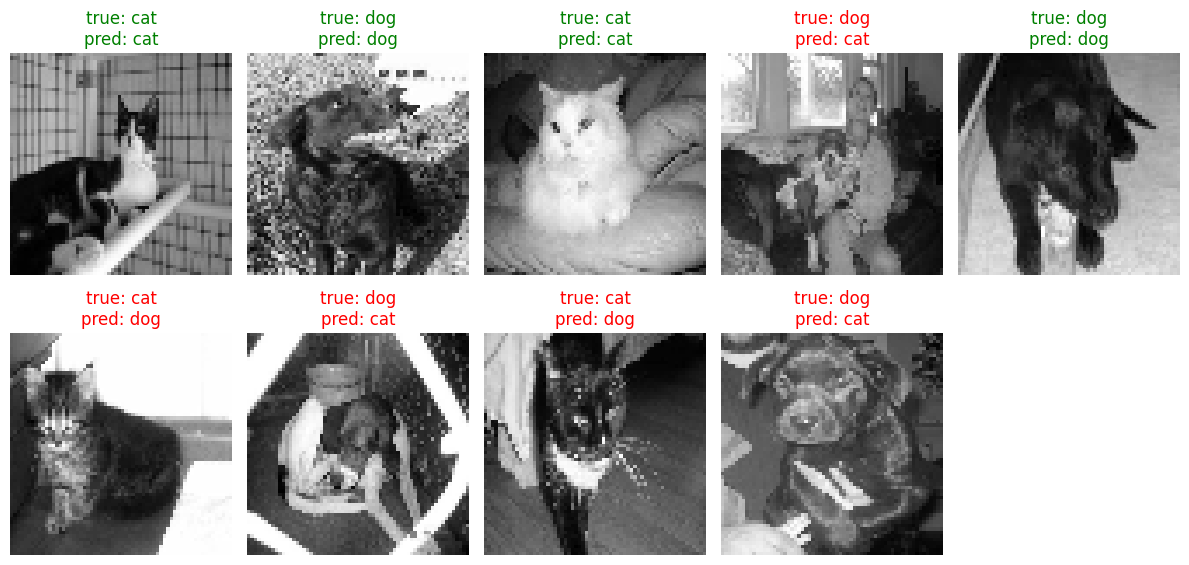

In [17]:
y_pred = predict(X_test, parametres)

plt.figure(figsize=(12, 6))
for i in range(1, 10):
    plt.subplot(2, 5, i)
    plt.imshow(X_test[:, i].reshape(64, 64), cmap='gray')
    true_label = 'dog' if y_test[0, i] == 1 else 'cat'
    pred_label = 'dog' if y_pred[0, i] else 'cat'
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"true: {true_label}\npred: {pred_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 7. Save parameters (streamlit)

In [18]:
with open("catdog_scratch_params.pkl", "wb") as f:
    pickle.dump(parametres, f)

print("Saved parameters to catdog_scratch_params.pkl")

Saved parameters to catdog_scratch_params.pkl
